In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

In [2]:
import json
import numpy as np
from src.data_loader import load_raw_data
from src.preprocessing import clean_raw_data, chronological_split, fit_scaler, apply_scaler, inverse_transform_column
from src.feature_engineering import build_features
from src.sequence_builder import create_sequences_for_all_splits
from src.evaluation.metrics import evaluate_all
from src.config import MODEL_FEATURE_COLUMNS, TARGET_COL, DEFAULT_LOOKBACK, FORECAST_HORIZON

DEV_LOOKBACK = 72  # temporary, for fast iteration — NOT the final 168

df_raw = load_raw_data()
df_clean = clean_raw_data(df_raw)
df_features = build_features(df_clean)
splits = chronological_split(df_features)

scale_columns = MODEL_FEATURE_COLUMNS + [TARGET_COL]
scaler = fit_scaler(splits.train, scale_columns)

train_scaled = apply_scaler(splits.train, scaler, scale_columns)
val_scaled = apply_scaler(splits.val, scaler, scale_columns)
test_scaled = apply_scaler(splits.test, scaler, scale_columns)

sequences = create_sequences_for_all_splits(train_scaled, val_scaled, test_scaled, MODEL_FEATURE_COLUMNS)
X_train, y_train_scaled = sequences["train"]
X_val, y_val_scaled = sequences["val"]
X_test, y_test_scaled = sequences["test"]

print("Ready:", X_train.shape, X_val.shape, X_test.shape)

2026-09-11 17:17:38 | INFO     | src.data_loader | Loading raw dataset from C:\Users\Ram\OneDrive\Desktop\energy-demand-lstm\data\raw\continuous_dataset.csv
2026-09-11 17:17:39 | INFO     | src.data_loader | Loaded raw dataset: 48048 rows, 17 columns
2026-09-11 17:17:40 | INFO     | src.preprocessing | Cleaning complete: 48048 rows, 4 flagged as diagnostic extreme events (|z| > 4.0)
2026-09-11 17:17:40 | INFO     | src.feature_engineering | Added national weather averages: temp_avg, humidity_avg, precip_avg, wind_avg
2026-09-11 17:17:40 | INFO     | src.feature_engineering | Added calendar features and cyclical encodings
2026-09-11 17:17:40 | INFO     | src.feature_engineering | Added lag features: ['lag_1', 'lag_24', 'lag_48', 'lag_168']
2026-09-11 17:17:40 | INFO     | src.feature_engineering | Added rolling features: rolling_mean_24, rolling_std_24, rolling_mean_168
2026-09-11 17:17:41 | INFO     | src.feature_engineering | Feature engineering complete: 48048 rows before, 47880 rows

In [3]:
import os
import torch
torch.set_num_threads(os.cpu_count())

from src.models.attention_lstm import AttentionLSTMForecaster
from src.training.trainer import train_model, predict

attn_model = AttentionLSTMForecaster(num_features=X_train.shape[2])
attn_history = train_model(attn_model, X_train, y_train_scaled, X_val, y_val_scaled, epochs=10)

print("Epochs trained:", attn_history["epochs_trained"])
print("Parameters:", attn_history["num_parameters"])
print("Training time (s):", round(attn_history["training_time_seconds"], 1))

2026-09-11 17:18:03 | INFO     | src.training.trainer | Training AttentionLSTMForecaster | 27800 parameters | device=cpu
2026-09-11 17:18:03 | INFO     | src.training.trainer |   batch 0/131
2026-09-11 17:18:53 | INFO     | src.training.trainer |   batch 100/131
2026-09-11 17:19:11 | INFO     | src.training.trainer | Epoch 1/10 | train_loss=0.055443 | val_loss=0.023453
2026-09-11 17:19:11 | INFO     | src.training.trainer |   batch 0/131
2026-09-11 17:19:51 | INFO     | src.training.trainer |   batch 100/131
2026-09-11 17:20:07 | INFO     | src.training.trainer | Epoch 2/10 | train_loss=0.021383 | val_loss=0.021603
2026-09-11 17:20:07 | INFO     | src.training.trainer |   batch 0/131
2026-09-11 17:20:46 | INFO     | src.training.trainer |   batch 100/131
2026-09-11 17:21:02 | INFO     | src.training.trainer | Epoch 3/10 | train_loss=0.020450 | val_loss=0.020002
2026-09-11 17:21:02 | INFO     | src.training.trainer |   batch 0/131
2026-09-11 17:21:42 | INFO     | src.training.trainer | 

In [4]:
from src.evaluation.metrics import evaluate_all
from src.preprocessing import inverse_transform_column
from src.config import TARGET_COL

y_pred_test_scaled = predict(attn_model, X_test)
y_true_attn = inverse_transform_column(y_test_scaled, scaler, scale_columns, TARGET_COL)
y_pred_attn = inverse_transform_column(y_pred_test_scaled, scaler, scale_columns, TARGET_COL)

attn_metrics = evaluate_all(y_true_attn, y_pred_attn)
print("Attention-LSTM:", attn_metrics)

Attention-LSTM: {'MAE': 86.76991752000143, 'RMSE': 112.72188666727624, 'MAPE': 7.3567807792619275, 'sMAPE': 7.257780439875641, 'R2': 0.6272591725350285}


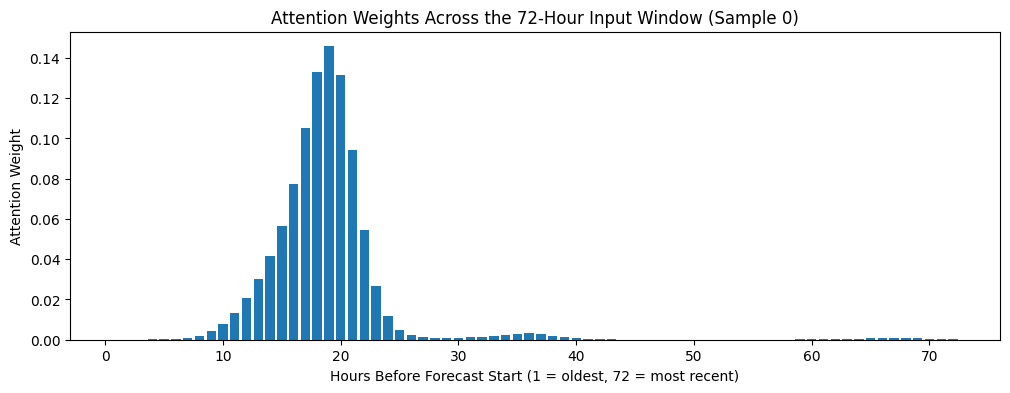

Sum of weights (should be ~1.0): 1.0
Most attended timestep (hours before forecast start): 19


In [5]:
import matplotlib.pyplot as plt
import numpy as np

sample_idx = 0  # first test sequence; we can pick a more interesting one after seeing this
sample_x = torch.from_numpy(X_test[sample_idx:sample_idx+1]).float()

attn_model.eval()
with torch.no_grad():
    _, attention_weights = attn_model(sample_x, return_attention=True)

weights = attention_weights.squeeze(0).numpy()  # shape (72,)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(1, len(weights) + 1), weights)
ax.set_xlabel("Hours Before Forecast Start (1 = oldest, 72 = most recent)")
ax.set_ylabel("Attention Weight")
ax.set_title("Attention Weights Across the 72-Hour Input Window (Sample 0)")
plt.show()

print("Sum of weights (should be ~1.0):", weights.sum())
print("Most attended timestep (hours before forecast start):", np.argmax(weights) + 1)

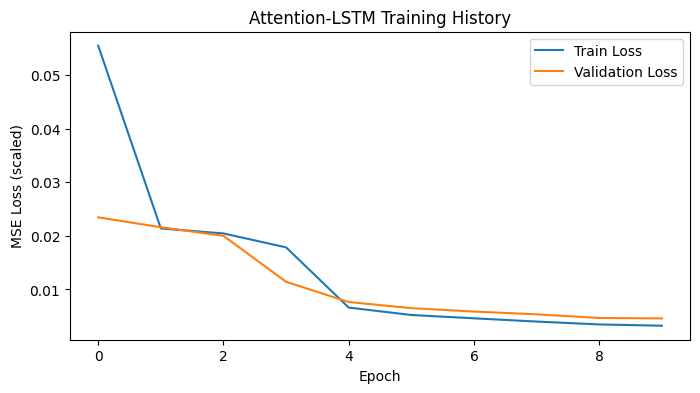

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(attn_history["train_loss"], label="Train Loss")
ax.plot(attn_history["val_loss"], label="Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss (scaled)")
ax.set_title("Attention-LSTM Training History")
ax.legend()
plt.show()

In [7]:
import json
from pathlib import Path
import pandas as pd

experiments_path = Path.cwd().parent / "experiments" / "model_comparison.json"
with open(experiments_path) as f:
    all_results = json.load(f)

all_results["Attention-LSTM"] = {
    **attn_metrics,
    "training_time_seconds": attn_history["training_time_seconds"],
    "num_parameters": attn_history["num_parameters"],
    "note": "Underperformed plain LSTM in our 10-epoch-capped experiments; loss curve suggests under-convergence rather than a fundamental architectural weakness. Not further tuned due to compute constraints.",
}
with open(experiments_path, "w") as f:
    json.dump(all_results, f, indent=2)

comparison = pd.DataFrame({
    "LSTM (1-layer)": all_results["LSTM"],
    "Attention-LSTM": attn_metrics,
}).T[["MAE", "RMSE", "MAPE", "sMAPE", "R2"]]
print(comparison)
print("\nSaved Attention-LSTM to experiments/model_comparison.json")

                      MAE        RMSE      MAPE     sMAPE        R2
LSTM (1-layer)  67.422624   93.767627  5.773968  5.654699  0.742073
Attention-LSTM  86.769918  112.721887  7.356781  7.257780  0.627259

Saved Attention-LSTM to experiments/model_comparison.json
